In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
# =========================
# 1️⃣ 读取 SWC
# =========================
def load_swc(path):
    return pd.read_csv(
        path,
        comment='#',
        sep=r'\s+',
        names=['id','type','x','y','z','r','parent']
    )


# =========================
# 2️⃣ 获取 soma（3D，稳健）
# =========================
def get_soma_3d(df):
    soma_nodes = df[df['type'] == 1]

    if len(soma_nodes) >=2:
        raise ValueError("More than one soma (type=1) found in SWC")

    # 多点平均（更稳定）
    return soma_nodes[['x','y','z']].mean().values


# =========================
# 3️⃣ SWC → edges（3D）
# =========================
def swc_to_edges_3d(df):
    dendrite = df[df["type"].isin([3])]

    segments = []
    for _, row in dendrite.iterrows():
        if row.parent == -1:
            continue

        parent = df[df["id"] == row.parent]
        if parent.empty:
            continue

        p1 = np.array([row.x, row.y, row.z])
        p2 = parent[["x", "y", "z"]].values[0]

        segments.append((p1, p2))

    return segments

# =========================
# 4️⃣ 线段-球面交点（3D，鲁棒）
# =========================
def segment_sphere_intersections(p1, p2, center, radius, eps=1e-6):

    p1 = np.asarray(p1)
    p2 = np.asarray(p2)
    c  = np.asarray(center)

    d = p2 - p1
    f = p1 - c

    a = np.dot(d, d)
    b = 2 * np.dot(d, f)
    c_coef = np.dot(f, f) - radius**2

    disc = b*b - 4*a*c_coef

    # 浮点稳定处理
    if disc < -eps:
        return []

    disc = max(disc, 0.0)
    sqrt_disc = np.sqrt(disc)

    t1 = (-b - sqrt_disc) / (2*a)
    t2 = (-b + sqrt_disc) / (2*a)

    pts = []
    for t in (t1, t2):
        if 0 <= t <= 1:
            pts.append(p1 + t*d)

    return pts


# =========================
# 5️⃣ Sholl profile（核心）
# =========================
def sholl_3d_profile(df, step=10, max_radius=None):

    soma = get_soma_3d(df)
    edges = swc_to_edges_3d(df)

    dendrite = df[df["type"].isin([3])]

    # 自动最大半径
    if max_radius is None:
        coords = dendrite[['x','y','z']].values
        dists = np.linalg.norm(coords - soma, axis=1)
        max_radius = np.max(dists)

    # 可选：避免边缘噪声
    max_radius = max_radius * 0.95

    radii = np.arange(step, max_radius, step)

    counts = []

    for r in radii:

        crossing_count = 0

        for p1, p2 in edges:
            pts = segment_sphere_intersections(p1, p2, soma, r)

            # ⭐ 关键：按“线段是否穿过”计数
            if len(pts) > 0:
                crossing_count += 1

        counts.append(crossing_count)

    return radii, np.array(counts)


# =========================
# 6️⃣ Sholl 曲线绘图
# =========================
def plot_sholl_curve(radii, counts,name):

    plt.figure(figsize=(6,5))

    plt.plot(radii, counts, marker='o')

    plt.xlabel("Radius (µm)")
    plt.ylabel("Sholl intersections")
    plt.title("%s 3D Sholl analysis"%name)

    plt.tight_layout()
    plt.savefig("%s 3D Sholl analysis.jpg"%name,dpi = 300)
    plt.close()


# =========================
# 7️⃣ 一体化 pipeline
# =========================
def run_sholl(swc_path, step=10, name= ""):

    df = load_swc(swc_path)

    radii, counts = sholl_3d_profile(df, step=step)

    plot_sholl_curve(radii, counts,name= name)

    return radii, counts


# =========================
# 8️⃣ Example
# =========================
# radii, counts = run_sholl("your_neuron.swc", step=10)

In [10]:
import glob,os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

swcs = glob.glob(r"J:\BLA_three_types\soma_sholl\BLA_swc_mirrow\*")
savepath = r"J:\BLA_three_types\soma_sholl"
# os.mkdir(savepath)
os.chdir(r"J:\BLA_three_types\soma_sholl")

In [3]:
neuron

NameError: name 'neuron' is not defined

In [11]:
for swc in tqdm(swcs):
    neuron = swc.split("\\")[-1][0:-4]
    try:


        radii, counts = run_sholl(swc, step=10,name = neuron)

        dftmp = pd.DataFrame(counts,index=radii,columns = [neuron])
        dftmp.to_csv(neuron+".csv")
    except:
        print(neuron)


100%|██████████| 39/39 [01:05<00:00,  1.68s/it]


In [12]:
files = glob.glob(r"J:\BLA_three_types\soma_sholl\*.csv")
dfall = pd.DataFrame()
for file in files:
    # print(file)
    df = pd.read_csv(file,index_col=0)
    dfall = pd.concat([dfall,df],axis=1)
dfall = dfall.fillna(0).T
dfall.to_csv(".\\all_neurons_sholl.csv")

In [4]:
os.chdir(r"J:\BLA_three_types\soma_sholl\plots")

In [7]:
dfall = pd.read_csv("all_neurons_sholl_geno.csv",index_col=0)

In [9]:
dfall["0.0"] = 0

In [10]:
dfall

,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,100.0,...,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0,cluster,0.0
251034_010_Vglut1,9.0,9.0,15.0,19.0,26.0,31.0,29.0,29.0,32.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Vglut1,0
234172_015_Crh,3.0,5.0,12.0,13.0,19.0,18.0,15.0,14.0,10.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
221058_038_Sst,6.0,12.0,16.0,17.0,19.0,18.0,15.0,15.0,13.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
221058_107_Sst,3.0,4.0,8.0,8.0,9.0,10.0,12.0,14.0,14.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
221297_038_Sst,2.0,9.0,16.0,18.0,19.0,21.0,22.0,21.0,18.0,16.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
234172_031_Crh,4.0,6.0,15.0,19.0,23.0,23.0,18.0,14.0,8.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
252460_132_Sst,7.0,6.0,6.0,6.0,6.0,7.0,8.0,9.0,12.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
221058_040_Sst,6.0,5.0,6.0,6.0,8.0,9.0,10.0,10.0,11.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
234172_016_Crh,3.0,4.0,9.0,13.0,16.0,22.0,14.0,11.0,12.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
242655_057_Sst,5.0,5.0,5.0,6.0,7.0,7.0,9.0,9.0,9.0,11.0,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Sst,0


In [16]:
dfall2 = pd.read_excel("BLA_3_cluster5.xlsx",index_col=0)

In [21]:
dfall = dfall.loc[dfall2.index.tolist(),:]

In [18]:
dfall2.index.tolist()

['251034_010_Vglut1',
 '234172_015_Crh',
 '221058_038_Sst',
 '221058_107_Sst',
 '221297_038_Sst',
 '234172_031_Crh',
 '252460_132_Sst',
 '221058_040_Sst',
 '234172_016_Crh',
 '242655_057_Sst',
 '234172_017_Crh',
 '251039_029_Vglut1',
 '230058_076_Sst',
 '230058_078_Sst',
 '252459_079_Sst',
 '230058_074_Sst',
 '251039_021_Vglut1',
 '251034_001_Vglut1',
 '234172_020_Crh',
 '221058_071_Sst',
 '221297_036_Sst',
 '221058_104_Sst',
 '252459_074_Sst',
 '234172_019_Crh',
 '221297_037_Sst',
 '230058_073_Sst',
 '234172_122_Crh',
 '234172_086_Crh',
 '251039_020_Vglut1',
 '251039_033_Vglut1',
 '234172_021_Crh',
 '221058_088_Sst',
 '251039_031_Vglut1',
 '221058_113_Sst',
 '251034_003_Vglut1',
 '251034_004_Vglut1',
 '234172_034_Crh',
 '251039_022_Vglut1']

In [13]:
dfall2["file2"] = dfall2.index+"_"+dfall2.location+"_"+dfall2.type

In [15]:
dfall2.to_excel("BLA_CCK_all_infor_type_new.xlsx")

In [22]:
# dfc = pd.read_csv("all_terminal_infor_table_dendrite_intensity_cluster.csv",index_col=0)
dfall2 = pd.concat([dfall2[["cluster"]],dfall],axis=1)
dfall2.to_csv("all_neurons_sholl_cluster.csv")

In [2]:
dfall["cluster"] = [item.split("_")[-1] for item in dfall.index.tolist()]

NameError: name 'dfall' is not defined

In [46]:
dfall.to_csv("all_neurons_sholl_geno.csv")

In [11]:
dfall2 = dfall.reset_index()

In [12]:
dfall2

,index,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,...,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0,cluster,0.0
0,251034_010_Vglut1,9.0,9.0,15.0,19.0,26.0,31.0,29.0,29.0,32.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Vglut1,0
1,234172_015_Crh,3.0,5.0,12.0,13.0,19.0,18.0,15.0,14.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
2,221058_038_Sst,6.0,12.0,16.0,17.0,19.0,18.0,15.0,15.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
3,221058_107_Sst,3.0,4.0,8.0,8.0,9.0,10.0,12.0,14.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
4,221297_038_Sst,2.0,9.0,16.0,18.0,19.0,21.0,22.0,21.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
5,234172_031_Crh,4.0,6.0,15.0,19.0,23.0,23.0,18.0,14.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
6,252460_132_Sst,7.0,6.0,6.0,6.0,6.0,7.0,8.0,9.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
7,221058_040_Sst,6.0,5.0,6.0,6.0,8.0,9.0,10.0,10.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sst,0
8,234172_016_Crh,3.0,4.0,9.0,13.0,16.0,22.0,14.0,11.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Crh,0
9,242655_057_Sst,5.0,5.0,5.0,6.0,7.0,7.0,9.0,9.0,9.0,...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Sst,0


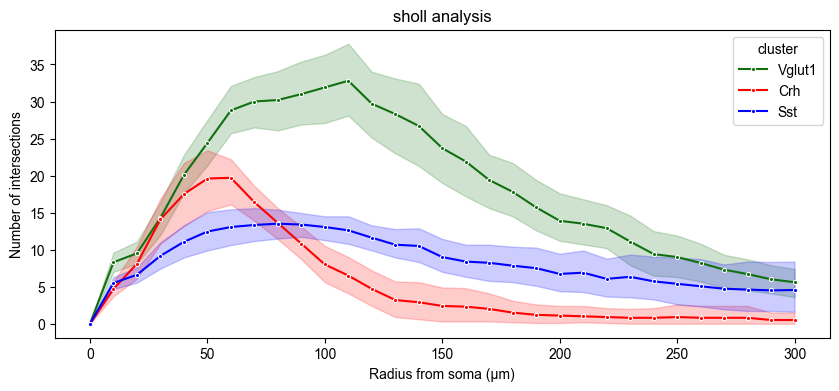

In [13]:
df_long = dfall2.melt(
    id_vars=['index', 'cluster'],  # 保留 sample 和 cluster
    var_name='x',                  # 原来的 10,20,30 → x
    value_name='value'             # 数值
)
df_long["x"] = pd.to_numeric(df_long["x"])
df_long2 = df_long.loc[df_long.x<=300]
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

plt.figure(figsize=(10,4))

dic_list = {"Vglut1":'#107010',"Sst":'#0000ff',"Crh":'red'}

sns.lineplot(
    data=df_long2,
    x='x',          # 横轴
    y='value',      # 纵轴
    hue='cluster',  # 按 cluster 分组
    marker='.',
    palette = dic_list
)

plt.ylabel("Number of intersections")
plt.xlabel("Radius from soma (µm)")
plt.title('sholl analysis')
plt.savefig("sholl analysis_geno_base2.pdf",dpi=300)
plt.savefig("sholl analysis_geno_base2.jpg",dpi=300)